# 卤水开采与水文地球化学反馈

论文图 10–12。四个情景使用相同网格、初始场和外部边界，仅切换密度与孔隙度–渗透系数反馈。

直接运行本笔记本即可从已保存结果重绘；不会启动 MODFLOW 或 PHREEQC。`python run.py` 依次运行四种情景并复用已完成的相同配置；新算例可用 `python run.py --scenario S11 --label S11_repeat`。时间步对照使用 `--dt 2`，网格对照使用 `--nx 400 --nz 100 --dt 2 --days 400`，各自指定新标签。

In [5]:
import sys
from pathlib import Path

sys.dont_write_bytecode = True
CASE_NAME = "ex021_Brine_Feedback2D"
candidates = (
    candidate
    for base in (Path.cwd(), *Path.cwd().parents)
    for candidate in (base, base / "examples" / CASE_NAME)
)
CASE_DIR = next(
    (
        path.resolve()
        for path in candidates
        if path.name == CASE_NAME and (path / "modflow_model.py").is_file()
    ),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{CASE_NAME} from {Path.cwd()}")
EXAMPLES_DIR = CASE_DIR.parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from example_utils import load_results, read_headings, restore_archives, runtime_path, time_indices

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
restore_archives(OUTPUT_DIR)
restore_archives(SIMULATION_DIR)


# Shallow recharge and brine recovery

Chapter 4 compares S00 (fixed density and structure), S10 (density feedback), S01 (porosity–K feedback), and S11 (both). Every scenario retains the same five-mineral chemistry, forcing and initial field.

The confined saturated section is 400 m long, 100 m deep and 1 m wide. Array row zero is the surface layer. Plot depth increases downward; q_depth = -q_z, with no row reversal. Left recharge is uniform over depth 0–10 m, total 5 m³/d. Right recovery is restricted to depth 0–20 m and uses an outflow-only head-dependent sink, Q_i = C_i max(h_i - 110 m, 0), implemented by DRN. Total screen conductance is 100 m²/d, equally distributed and fixed. This is a conceptual pressure-controlled recovery screen, not a resolved multi-aquifer well. All other boundaries are impermeable; the surface elevation datum is 100 m.

input_data/hk.npy is the unchanged supplied 100 × 400 Gaussian conductivity realization, interpreted in m/d. The primary 50 × 200 field uses geometric means of 2 × 2 blocks; the fine grid uses the source directly. No amplitude adjustment or realization selection is performed. Vertical/horizontal K ratio is 0.3. Initial porosity is 0.20; bulk fractions of halite, carnallite, sylvite, gypsum, polyhalite and inert framework are 0.40, 0.16, 0.015, 0.025, 0.04 and 0.16. Pitzer equilibrium chemistry uses 25 °C and 1 atm. Initial brine is pre-equilibrated with all five minerals; recharge is halite-saturated. Conditioning solids remain outside the domain.

Primary simulations use SNIA, TVD, 4 d steps through 2400 d, dispersivities 2/0.2 m, and fixed diffusion 8.64e-5 m²/d. Evolving K follows Kozeny–Carman. The case driver re-queries PhreeqcRM concentrations after setting porosity to conserve aqueous component moles across the volume-basis handoff. Framework source is imported from the repository and is not modified.

## Results and boundaries

Only output/<label>/status.json with completed: true identifies a complete run. Metadata records input, database and conductivity hashes. results.npy uses results_headings.txt and results_times.npy; minerals are mol/L bulk volume and RHO is kg/L. aqueous_transport.npy stores reaction-end concentrations after the porosity commit, in mol/L pore volume. heads.npy and outlet_flux.npy omit the initial frame. simulation/<label>/flow.bud stores saved Darcy fluxes. Flow precedes reaction/property output by at most one coupling step.

Overall removal uses signed net mineral loss; positive local loss is used only for the reaction centroid. Cumulative K output follows the aqueous-plus-solid inventory balance and known input; it includes displaced initial-brine K and is not a mineral-specific recovery factor. Top-20% flux concentration near x=300 m is a descriptive cell-centred diagnostic, not a face-budget integration.

Na, K, Mg, Ca, Cl and S balances do not establish full H/O, fluid-volume or mechanical closure. This fixed-volume quasi-steady model does not explicitly supply water to newly created pores or model deformation, unsaturation, viscosity feedback or cavity geometry. Results are a conditional demonstration using one realization and an empirical porosity–K law, not calibrated field predictions.

## 从保存的模型与反应结果提取物理量

读取 `output/<情景>/` 的状态数组、组分清单和时间，以及 `simulation/<情景>/flow.bud` 中的 Darcy 通量。`output/analysis/` 保存原有后处理结果。

In [6]:
from ex021_Brine_Feedback2D.run import (
    CASE_DIR,
    INERT_FRACTION,
    POROSITY,
    SCENARIOS,
    MINERAL_MOLAR_VOLUMES,
    Config,
    ChemistryConfig,
)
import csv
import hashlib
import json
from dataclasses import fields
import flopy
import numpy as np
from scipy.ndimage import label as connected_components

from ex021_Brine_Feedback2D.run import CHEMISTRY

DEST = OUTPUT_DIR / "analysis"


def load(label: str, *, chemistry: ChemistryConfig) -> dict:
    p = OUTPUT_DIR / label
    status = json.loads((p / "status.json").read_text())
    if not status.get("completed"):
        raise RuntimeError(f"{label} is incomplete")
    meta = json.loads((p / "metadata.json").read_text())
    if "chemistry" in meta:
        chemistry = ChemistryConfig(**meta["chemistry"])
    config = Config(
        **{k: v for k, v in meta["config"].items() if k in {f.name for f in fields(Config)}}
    )
    r, headings, times = load_results(p)
    phi = np.load(p / "results_porosity.npy")
    k = np.load(p / "results_K.npy")
    aq = np.load(p / "aqueous_transport.npy")
    k0 = np.load(p / "initial_K.npy")
    mineral = np.stack([r[:, headings.index(m)] for m in chemistry.mineral_molar_volumes], axis=1)
    carn = mineral[:, 1]
    depletion = (carn[0] - carn) / carn[0]
    bud = flopy.utils.CellBudgetFile(str(SIMULATION_DIR / label / "flow.bud"), precision="double")
    qx = []
    qz = []
    for t in times[1:]:
        sp = bud.get_data(text="DATA-SPDIS", totim=float(t))[0]
        qx.append(sp["qx"].reshape(config.nz, config.nx))
        qz.append(sp["qz"].reshape(config.nz, config.nx))
    bud.close()
    qx = np.stack([qx[0], *qx])
    qz = np.stack([qz[0], *qz])
    hist = json.loads((p / "history.json").read_text())
    heads = np.load(p / "heads.npy").reshape(-1, config.nz, config.nx)
    heads = np.concatenate([heads[:1], heads])
    krow = meta["components"].index("K")
    potassium = (aq[:, krow] * phi).sum(axis=1) + (
        mineral[:, 1] + mineral[:, 2] + 2 * mineral[:, 4]
    ).sum(axis=1)
    potassium *= config.cell_volume * 1000
    recovered = (
        potassium[0]
        + config.injection_rate * meta["injection_mol_L"][krow] * times * 1000
        - potassium
    )
    return dict(
        meta=meta,
        config=config,
        chemistry=chemistry,
        results=r,
        headings=headings,
        times=times,
        phi=phi,
        k=k,
        k0=k0,
        aq=aq,
        mineral=mineral,
        depletion=depletion,
        qx=qx,
        qz=qz,
        hist=hist,
        heads=heads,
        recovered_K_mol=recovered,
    )


def frame(d, day):
    return int(time_indices(d["times"], [day])[0])


def focus(d):
    ix = int(np.argmin(abs(d["config"].x - 300)))
    profiles = np.maximum(d["qx"][:, :, ix], 0.0)
    n = int(np.ceil(d["config"].nz * 0.2))
    return np.sort(profiles, axis=1)[:, -n:].sum(axis=1) / profiles.sum(axis=1)


def metrics(d):
    chemistry = d["chemistry"]
    config = d["config"]
    r = d["results"]
    h = d["hist"]
    mol = d["mineral"]
    v = np.array(list(chemistry.mineral_molar_volumes.values()))
    closure = d["phi"] + np.einsum("tmn,m->tn", mol, v) + chemistry.inert_fraction
    final_depl = d["depletion"][-1].reshape(config.nz, config.nx)
    mask = (final_depl >= 0.8) & ((d["k"][-1] / d["k0"]).reshape(config.nz, config.nx) >= 3.0)
    cc, n = connected_components(mask)
    inlet_labels = np.unique(cc[config.inlet_layers, 0])
    inlet_labels = inlet_labels[inlet_labels > 0]
    connected = np.isin(cc, inlet_labels)
    reach = float(config.x[np.any(connected, axis=0)].max()) if connected.any() else 0.0
    phase_change = (mol[0].sum(axis=1) - mol[-1].sum(axis=1)) * config.cell_volume * 1000
    pore_change = phase_change * v / 1000
    concentration = focus(d)
    ix = int(np.argmin(abs(config.x - 300)))
    final_q = np.maximum(d["qx"][-1, :, ix], 0.0)
    equilibrium = {}
    for j, name in enumerate(chemistry.mineral_molar_volumes):
        si = r[:, d["headings"].index("SI_" + name)]
        present = mol[:, j] > 1e-08
        equilibrium[name] = {
            "max_abs_SI_present": float(np.max(np.abs(si[present]))) if present.any() else None,
            "max_SI_all_cells": float(si.max()),
            "min_mol_L_bulk": float(mol[:, j].min()),
        }
    return dict(
        scenario=d["meta"]["scenario"],
        days=config.days,
        nx=config.nx,
        nz=config.nz,
        dt=config.dt,
        final_injection_head_m=float(d["heads"][-1, config.inlet_layers, 0].mean()),
        final_injection_head_excess_m=float(
            d["heads"][-1, config.inlet_layers, 0].mean() - config.outlet_head
        ),
        recovered_K_mol=float(d["recovered_K_mol"][-1]),
        recovered_K_per_injected_m3=float(
            d["recovered_K_mol"][-1] / (config.injection_rate * config.days)
        ),
        carnallite_removed_fraction=float((mol[0, 1].sum() - mol[-1, 1].sum()) / mol[0, 1].sum()),
        mineral_net_dissolved_mol=dict(
            zip(chemistry.mineral_molar_volumes, phase_change.tolist(), strict=False)
        ),
        mineral_pore_volume_contribution_m3=dict(
            zip(chemistry.mineral_molar_volumes, pore_change.tolist(), strict=False)
        ),
        net_pore_volume_change_m3=float((d["phi"][-1] - d["phi"][0]).sum() * config.cell_volume),
        equilibrium_audit=equilibrium,
        final_reaction_centroid_z_m=h[-1]["carnallite_dissolution_centroid_z"],
        final_outlet_K_mol_L=h[-1]["outlet_K_mol_L"],
        final_outward_flow_m3_d=h[-1]["outward_flow"],
        final_backflow_m3_d=h[-1]["backflow"],
        cumulative_outward_volume_m3=sum(x["outward_flow"] for x in h) * config.dt,
        cumulative_backflow_volume_m3=sum(x["backflow"] for x in h) * config.dt,
        max_phi=max(float(d["phi"].max()), max(x["max_phi"] for x in h)),
        min_phi=min(float(d["phi"].min()), min(x["min_phi"] for x in h)),
        max_k_ratio=max(float(np.max(d["k"] / d["k0"])), max(x["max_k_ratio"] for x in h)),
        mean_phi_final=float(d["phi"][-1].mean()),
        density_min_kg_m3=float(r[:, d["headings"].index("RHO")].min() * 1000),
        density_max_kg_m3=float(r[:, d["headings"].index("RHO")].max() * 1000),
        max_salt_inventory_error_fraction=max(x["max_mass_error_fraction"] for x in h),
        max_flow_imbalance_fraction=max(
            abs(x["net_outflow"] - config.injection_rate) / config.injection_rate for x in h
        ),
        max_backflow_m3_d=max(x["backflow"] for x in h),
        max_bulk_volume_closure_error=float(np.max(abs(closure - 1))),
        max_relative_solution_pore_volume_difference=float(
            np.max(abs(r[:, d["headings"].index("solution_L")] / d["phi"] - 1))
        ),
        volume_closure_applicable=d["meta"]["scenario"][2] == "1",
        initial_flux_top20_fraction=float(concentration[0]),
        final_flux_top20_fraction=float(concentration[-1]),
        peak_flux_top20_fraction=float(concentration.max()),
        peak_flux_top20_day=float(d["times"][np.argmax(concentration)]),
        flux_diagnostic_x_m=float(config.x[ix]),
        final_positive_flux_centroid_z_m=float(final_q @ config.z / final_q.sum()),
        carnallite_depletion_min=float(d["depletion"].min()),
        carnallite_depletion_max=float(d["depletion"].max()),
        channel_reach_m=reach,
        channel_thresholds={"carnallite_depletion": 0.8, "K_over_K0": 3, "neighbours": 4},
        channel_connects_recovery_screen=bool(connected[config.outlet_layers, -1].any()),
        initial_K_geometric_mean=float(np.exp(np.log(d["k0"]).mean())),
        initial_K_min=float(d["k0"].min()),
        initial_K_max=float(d["k0"].max()),
        min_equilibrium_moles=float(mol.min()),
    )


def export(d, label):
    chemistry = d["chemistry"]
    flux_fraction = focus(d)
    config = d["config"]
    p = DEST / f"{label}_fields.npz"
    np.savez_compressed(
        p,
        time_days=d["times"],
        x_m=config.x,
        z_m=config.z,
        density_kg_m3=d["results"][:, d["headings"].index("RHO")].reshape(-1, config.nz, config.nx)
        * 1000,
        carnallite_depletion=d["depletion"].reshape(-1, config.nz, config.nx),
        porosity=d["phi"].reshape(-1, config.nz, config.nx),
        K_m_d=d["k"].reshape(-1, config.nz, config.nx),
        K0_m_d=d["k0"].reshape(config.nz, config.nx),
        qx_m_d=d["qx"],
        qz_m_d=d["qz"],
        mineral_mol_L_bulk=d["mineral"],
        mineral_names=np.array(list(chemistry.mineral_molar_volumes)),
        transport_mol_L=d["aq"],
        component_names=np.array(d["meta"]["components"]),
        flux_top20_fraction=flux_fraction,
        depth_m=config.height - config.z,
        head_m=d["heads"],
        recovered_K_mol=d["recovered_K_mol"],
        injection_head_m=d["heads"][:, config.inlet_layers, 0].mean(axis=1),
    )
    records = []
    for h in d["hist"]:
        records.append({k: v for k, v in h.items() if not isinstance(v, list)})
    with (DEST / f"{label}_history.csv").open("w", newline="", encoding="utf-8-sig") as f:
        w = csv.DictWriter(f, fieldnames=records[0])
        w.writeheader()
        w.writerows(records)
    net = (
        (d["mineral"][0].sum(axis=1)[None, :] - d["mineral"].sum(axis=2))
        * config.cell_volume
        * 1000
    )
    snapshots = []
    for i, t in enumerate(d["times"]):
        row = {"time_days": float(t), "flux_top20_fraction": float(flux_fraction[i])}
        row.update(
            {
                f"net_{name}_removed_mol": float(net[i, j])
                for j, name in enumerate(chemistry.mineral_molar_volumes)
            }
        )
        snapshots.append(row)
    with (DEST / f"{label}_snapshot_metrics.csv").open("w", newline="", encoding="utf-8-sig") as f:
        w = csv.DictWriter(f, fieldnames=snapshots[0])
        w.writeheader()
        w.writerows(snapshots)
    return hashlib.sha256(p.read_bytes()).hexdigest()


In [7]:
ds = {s: load(s + "_shallow",
chemistry=CHEMISTRY
) for s in SCENARIOS}
assert len({d["meta"]["k_sha256"] for d in ds.values()}) == 1
for s, d in ds.items():
    assert np.all(np.isfinite(d["results"]))
    assert np.all(np.diff(d["times"]) > 0)
    print(s, d["config"].shape, d["times"][-1], "days")


S00 (50, 1, 200) 2400.0 days
S10 (50, 1, 200) 2400.0 days
S01 (50, 1, 200) 2400.0 days
S11 (50, 1, 200) 2400.0 days


## 论文图 10

以下代码保持论文图的配色、字体、面板尺寸和标注，读取本案例的 `input_data/`、`output/` 与 `simulation/`。结果图保存到 `output/figures/`。

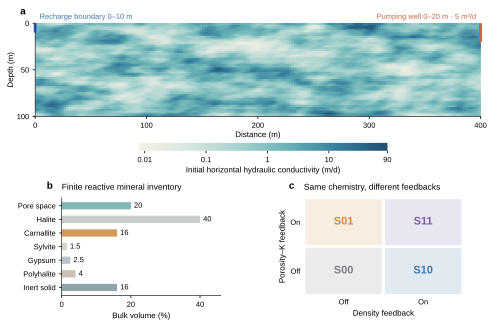

In [8]:
BASE = OUTPUT_DIR / "figures"
BASE.mkdir(exist_ok=True)

import string

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, PowerNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import ScaledTranslation

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

W = 183 / 25.4


COLORS = ["#7A7F87", "#3E79A8", "#D18A3F", "#7B5EA7"]

LABELS = [
    "S00 · Fixed properties",
    "S10 · Density feedback",
    "S01 · Porosity–K feedback",
    "S11 · Both feedbacks",
]
LINESTYLES = ["--", "-.", ":", "-"]


KMAP = LinearSegmentedColormap.from_list(
    "hydraulic", ["#F6F1E6", "#D8E6DF", "#A8D3CE", "#68B2B7", "#367F9D", "#204E70"]
)

DMAP = LinearSegmentedColormap.from_list(
    "dissolution", ["#fbfaf5", "#e2efde", "#afdad0", "#62b9b2", "#168d96"]
)
QMAP = LinearSegmentedColormap.from_list(
    "flow", ["#fffdf7", "#cae5dc", "#76bdbb", "#348d9b", "#225f7b"]
)
CMAP = LinearSegmentedColormap.from_list(
    "potassium", ["#fcf9f1", "#f3dfb4", "#e3b97f", "#cf855f", "#a85858"]
)
RMAP = LinearSegmentedColormap.from_list(
    "enhancement", ["#fcfaf5", "#f4e3bc", "#e8bc76", "#cf874b", "#a75c3e"]
)


plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": ["Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.titlesize": 8.5,
        "axes.labelsize": 8,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.facecolor": "white",
    }
)


from ex021_Brine_Feedback2D.run import MINERAL_VOLUME_FRACTIONS

D = {
    "K0": ds["S00"]["k0"].reshape(ds["S00"]["config"].nz, ds["S00"]["config"].nx),
    "mineral_names": np.array(["Pore space", *MINERAL_VOLUME_FRACTIONS, "Inert solid"]),
    "bulk_volume_percent": np.array([POROSITY, *MINERAL_VOLUME_FRACTIONS.values(), INERT_FRACTION])
    * 100,
}


def _manuscript_layout_10(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [(0, 0), (26.592977, 0), (-17.682054, 0), (0, 0)]
    if len(fig.axes) != len(offsets):
        raise ValueError("Manuscript panel count changed")
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])


def panel(ax, letter, title):
    ax.set_title(title, loc="left", pad=8, fontweight="normal")
    ax.text(
        0,
        1,
        letter,
        transform=ax.transAxes + ScaledTranslation(-15 / 72, 7 / 72, ax.figure.dpi_scale_trans),
        fontsize=10,
        fontweight="bold",
        va="bottom",
    )


def field(ax, a, cmap, norm, xlabel=True, ylabel=True):

    im = ax.imshow(
        a,
        origin="upper",
        extent=(0, 400, 100, 0),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    ax.set(xlim=(0, 400), ylim=(100, 0), xticks=[0, 100, 200, 300, 400], yticks=[0, 50, 100])
    ax.tick_params(labelbottom=xlabel, labelleft=ylabel)
    if xlabel:
        ax.set_xlabel("Distance (m)", labelpad=2)
    if ylabel:
        ax.set_ylabel("Depth (m)", labelpad=2)

    ax.plot([0, 0], [0, 10], color="#3E79A8", lw=3, clip_on=False, solid_capstyle="butt")
    ax.plot([400, 400], [0, 20], color="#C66A45", lw=3, clip_on=False, solid_capstyle="butt")
    return im


def bar(fig, im, rect, label, ticks=None):
    ca = fig.add_axes(rect)
    cb = fig.colorbar(im, cax=ca, orientation="horizontal", ticks=ticks)
    cb.set_label(label, labelpad=3)
    cb.outline.set_visible(False)
    cb.ax.minorticks_off()
    if ticks is not None:
        cb.ax.set_xticklabels([f"{t:g}" for t in ticks])


def finish(fig, n, axes):
    _manuscript_layout_10(fig)
    fig.savefig(BASE / f"figure_{n:02}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    plt.close(fig)


def figure10(D):
    fig = plt.figure(figsize=(W, 4.8))
    gs = fig.add_gridspec(
        2,
        2,
        left=0.10,
        right=0.96,
        bottom=0.12,
        top=0.91,
        height_ratios=[1, 1.05],
        hspace=0.85,
        wspace=0.8,
    )
    a = fig.add_subplot(gs[0, :])
    b = fig.add_subplot(gs[1, 0])
    config = fig.add_subplot(gs[1, 1])

    im = field(a, D["K0"], KMAP, LogNorm(0.008, 90))
    panel(a, "a", "")

    a.text(
        0.01,
        1.03,
        "Recharge boundary 0–10 m",
        transform=a.transAxes,
        color="#3E79A8",
        fontsize=7.5,
        va="bottom",
    )

    a.text(
        0.99,
        1.03,
        "Pumping well 0–20 m · 5 m³/d",
        transform=a.transAxes,
        color="#C66A45",
        fontsize=7.5,
        ha="right",
        va="bottom",
    )

    a.set_title("")

    bar(
        fig,
        im,
        [0.30, 0.54, 0.48, 0.021],
        "Initial horizontal hydraulic conductivity (m/d)",
        [0.01, 0.1, 1, 10, 90],
    )

    names = D["mineral_names"]
    vals = D["bulk_volume_percent"]

    b.barh(
        range(7),
        vals,
        height=0.53,
        color=["#80B7B2", "#C7CBCB", "#D49A57", "#D8D2C8", "#B9C6C9", "#C9C1B5", "#8FA5AA"],
    )

    b.set_yticks(range(7), names)
    b.invert_yaxis()
    b.set_xlim(0, 46)
    b.set_xticks([0, 20, 40])
    b.set_xlabel("Bulk volume (%)")
    for i, v in enumerate(vals):
        b.text(v + 0.9, i, f"{v:g}", va="center", fontsize=7.5)

    panel(b, "b", "Finite reactive mineral inventory")

    for i, (x, y) in enumerate([(0, 0), (1, 0), (0, 1), (1, 1)]):
        config.add_patch(
            Rectangle((x, y), 1, 1, facecolor=COLORS[i], alpha=0.16, edgecolor="white", lw=3)
        )
        config.text(
            x + 0.5,
            y + 0.51,
            ["S00", "S10", "S01", "S11"][i],
            ha="center",
            va="center",
            color=COLORS[i],
            fontweight="bold",
            fontsize=11,
        )

    config.set(xlim=(0, 2), ylim=(0, 2), xticks=[0.5, 1.5], yticks=[0.5, 1.5])
    config.set_xticklabels(["Off", "On"])
    config.set_yticklabels(["Off", "On"])
    config.set_xlabel("Density feedback")
    config.set_ylabel("Porosity–K feedback")
    config.tick_params(length=0)

    for sp in config.spines.values():
        sp.set_visible(False)

    panel(config, "c", "Same chemistry, different feedbacks")
    finish(fig, 10, [a, b, config])


np.savez_compressed(BASE / "figure_10_data.npz", **D)
figure10(D)


## 论文图 11

以下代码保持论文图的配色、字体、面板尺寸和标注，读取本案例的 `input_data/`、`output/` 与 `simulation/`。结果图保存到 `output/figures/`。

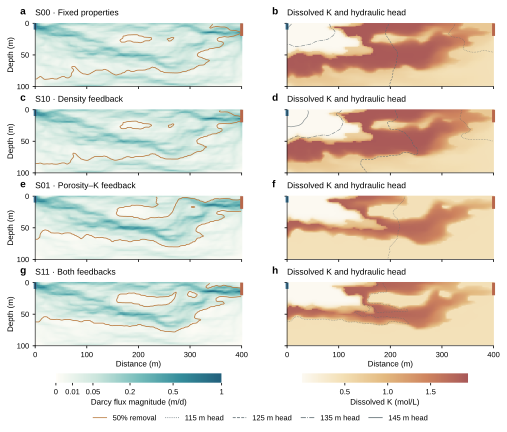

In [9]:
BASE = OUTPUT_DIR / "figures"
BASE.mkdir(exist_ok=True)


from matplotlib.colors import LinearSegmentedColormap

W = 183 / 25.4
COLORS = ["#80868c", "#427fa3", "#c89348", "#178d89"]
LABELS = [
    "S00 · Fixed properties",
    "S10 · Density feedback",
    "S01 · Porosity–K feedback",
    "S11 · Both feedbacks",
]
LINESTYLES = ["--", "-.", ":", "-"]
KMAP = LinearSegmentedColormap.from_list(
    "hydraulic", ["#fbf5df", "#d9e4cd", "#8cc5b9", "#408f9c", "#256178"]
)
DMAP = LinearSegmentedColormap.from_list(
    "dissolution", ["#fbfaf5", "#e2efde", "#afdad0", "#62b9b2", "#168d96"]
)
QMAP = LinearSegmentedColormap.from_list(
    "flow", ["#fffdf7", "#cae5dc", "#76bdbb", "#348d9b", "#225f7b"]
)
CMAP = LinearSegmentedColormap.from_list(
    "potassium", ["#fcf9f1", "#f3dfb4", "#e3b97f", "#cf855f", "#a85858"]
)
RMAP = LinearSegmentedColormap.from_list(
    "enhancement", ["#fcfaf5", "#f4e3bc", "#e8bc76", "#cf874b", "#a75c3e"]
)

plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": ["Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.titlesize": 8.5,
        "axes.labelsize": 8,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.facecolor": "white",
    }
)


scenarios = list(SCENARIOS)
config = ds["S00"]["config"]
D = {
    "K0": ds["S00"]["k0"].reshape(config.nz, config.nx),
    "x": config.x,
    "depth": config.height - config.z,
}
for key in ["depletion", "solute_K", "heads", "qx", "qz"]:
    frames = []
    for s in scenarios:
        d = ds[s]
        idx = frame(d, 1600)
        value = (
            d["aq"][idx, d["meta"]["components"].index("K")] if key == "solute_K" else d[key][idx]
        )
        frames.append(value.reshape(config.nz, config.nx))
    D[key] = np.stack(frames)
%matplotlib inline
%config InlineBackend.figure_format = 'svg'


def _manuscript_layout_11(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (0, -21.04069),
        (0, -21.04069),
        (0, -41.959318),
        (0, -41.959318),
        (0, -63),
        (0, -63),
        (0, -69),
        (0, -69),
    ]
    if len(fig.axes) != len(offsets):
        raise ValueError("Manuscript panel count changed")
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - -69 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def panel_section9(ax, letter, title):
    ax.set_title(title, loc="left", pad=8, fontweight="normal")
    ax.text(
        0,
        1,
        letter,
        transform=ax.transAxes + ScaledTranslation(-15 / 72, 7 / 72, ax.figure.dpi_scale_trans),
        fontsize=10,
        fontweight="bold",
        va="bottom",
    )


def field_section9(ax, a, cmap, norm, xlabel=True, ylabel=True):

    im = ax.imshow(
        a,
        origin="upper",
        extent=(0, 400, 100, 0),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    ax.set(xlim=(0, 400), ylim=(100, 0), xticks=[0, 100, 200, 300, 400], yticks=[0, 50, 100])
    ax.tick_params(labelbottom=xlabel, labelleft=ylabel)
    if xlabel:
        ax.set_xlabel("Distance (m)", labelpad=2)
    if ylabel:
        ax.set_ylabel("Depth (m)", labelpad=2)
    ax.plot([0, 0], [0, 10], color="#427fa3", lw=3, clip_on=False, solid_capstyle="butt")
    ax.plot([400, 400], [0, 20], color="#b8674b", lw=3, clip_on=False, solid_capstyle="butt")
    return im


def bar_section9(fig, im, rect, label, ticks=None):
    ca = fig.add_axes(rect)
    cb = fig.colorbar(im, cax=ca, orientation="horizontal", ticks=ticks)
    cb.set_label(label, labelpad=3)
    cb.outline.set_visible(False)
    cb.ax.minorticks_off()
    if ticks is not None:
        cb.ax.set_xticklabels([f"{t:g}" for t in ticks])


def finish_section9(fig, n, axes):
    _manuscript_layout_11(fig)
    fig.savefig(BASE / f"figure_{n:02}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    plt.close(fig)


def figure11(D):
    fig, axes = plt.subplots(4, 2, figsize=(W, 7.05))
    fig.subplots_adjust(left=0.095, right=0.98, bottom=0.18, top=0.94, wspace=0.22, hspace=0.70)
    cmin = float(D["solute_K"].min())
    cmax = float(D["solute_K"].max())
    hlevels = [115, 125, 135, 145]
    hstyles = [":", "--", "-.", "-"]
    for row in range(4):
        a, b = axes[row]
        speed = np.hypot(D["qx"][row], D["qz"][row])
        im1 = field_section9(a, speed, QMAP, PowerNorm(gamma=0.5, vmin=0, vmax=1), xlabel=row == 3)
        a.contour(
            D["x"], D["depth"], D["depletion"][row], levels=[0.5], colors="#b8793e", linewidths=0.8
        )
        im2 = field_section9(
            b, D["solute_K"][row], CMAP, Normalize(cmin, cmax), xlabel=row == 3, ylabel=False
        )
        b.contour(
            D["x"],
            D["depth"],
            D["heads"][row],
            levels=hlevels,
            colors="#59676d",
            linewidths=0.60,
            linestyles=hstyles,
            alpha=0.8,
        )
        panel_section9(a, string.ascii_lowercase[2 * row], LABELS[row])
        panel_section9(b, string.ascii_lowercase[2 * row + 1], "Dissolved K and hydraulic head")
    bar_section9(
        fig,
        im1,
        [0.135, 0.095, 0.32, 0.018],
        "Darcy flux magnitude (m/d)",
        [0, 0.01, 0.05, 0.2, 0.5, 1],
    )
    bar_section9(fig, im2, [0.61, 0.095, 0.32, 0.018], "Dissolved K (mol/L)")
    handles = [Line2D([], [], color="#b8793e", lw=0.8, label="50% removal")] + [
        Line2D([], [], color="#59676d", ls=ls, lw=0.8, label=f"{h} m head")
        for h, ls in zip(hlevels, hstyles, strict=False)
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.53, 0.005),
        columnspacing=1.2,
        handlelength=1.8,
    )
    finish_section9(fig, 11, list(axes.flat))


np.savez_compressed(BASE / "figure_11_data.npz", **D)
figure11(D)


## 论文图 12

以下代码保持论文图的配色、字体、面板尺寸和标注，读取本案例的 `input_data/`、`output/` 与 `simulation/`。结果图保存到 `output/figures/`。

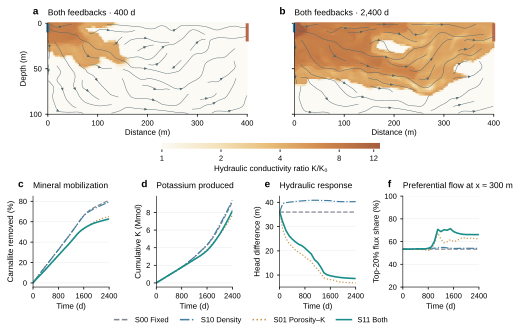

In [10]:
BASE = OUTPUT_DIR / "figures"
BASE.mkdir(exist_ok=True)


%matplotlib inline
%config InlineBackend.figure_format = 'svg'

W = 183 / 25.4
COLORS = ["#80868c", "#427fa3", "#c89348", "#178d89"]
LABELS = [
    "S00 · Fixed properties",
    "S10 · Density feedback",
    "S01 · Porosity–K feedback",
    "S11 · Both feedbacks",
]
LINESTYLES = ["--", "-.", ":", "-"]
KMAP = LinearSegmentedColormap.from_list(
    "hydraulic", ["#fbf5df", "#d9e4cd", "#8cc5b9", "#408f9c", "#256178"]
)
DMAP = LinearSegmentedColormap.from_list(
    "dissolution", ["#fbfaf5", "#e2efde", "#afdad0", "#62b9b2", "#168d96"]
)
QMAP = LinearSegmentedColormap.from_list(
    "flow", ["#fffdf7", "#cae5dc", "#76bdbb", "#348d9b", "#225f7b"]
)
CMAP = LinearSegmentedColormap.from_list(
    "potassium", ["#fcf9f1", "#f3dfb4", "#e3b97f", "#cf855f", "#a85858"]
)
RMAP = LinearSegmentedColormap.from_list(
    "enhancement", ["#fcfaf5", "#f4e3bc", "#e8bc76", "#cf874b", "#a75c3e"]
)

plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": ["Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.titlesize": 8.5,
        "axes.labelsize": 8,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.facecolor": "white",
    }
)


config = ds["S11"]["config"]
d = ds["S11"]
evolution_days = np.array([400, 2400])
idx = [frame(d, t) for t in evolution_days]
D = {
    "x": config.x,
    "depth": config.height - config.z,
    "time": d["times"],
    "evolution_days": evolution_days,
    "ratio": (d["k"][idx] / d["k0"]).reshape(-1, config.nz, config.nx),
    "evolution_qx": d["qx"][idx],
    "evolution_qz": d["qz"][idx],
}
D["removed"] = np.stack([d["depletion"].mean(axis=1) for d in ds.values()])
D["recovered"] = np.stack([d["recovered_K_mol"] for d in ds.values()])
D["head_excess"] = np.stack(
    [d["heads"][:, d["config"].inlet_layers, 0].mean(axis=1) - d["config"].outlet_head for d in ds.values()]
)
D["focus"] = np.stack([focus(d) for d in ds.values()])


def _manuscript_layout_12(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (-14.807232, -4.5),
        (-14.807232, -4.5),
        (-14.807232, -4.5),
        (-14.807232, -4.5),
        (0, -25.461447),
    ]
    if len(fig.axes) != len(offsets):
        raise ValueError("Manuscript panel count changed")
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + -14.807232 / width_pt, box.y0 - -15 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def panel_section11(ax, letter, title):
    ax.set_title(title, loc="left", pad=8, fontweight="normal")
    ax.text(
        0,
        1,
        letter,
        transform=ax.transAxes + ScaledTranslation(-15 / 72, 7 / 72, ax.figure.dpi_scale_trans),
        fontsize=10,
        fontweight="bold",
        va="bottom",
    )


def field_section11(ax, a, cmap, norm, xlabel=True, ylabel=True):

    im = ax.imshow(
        a,
        origin="upper",
        extent=(0, 400, 100, 0),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    ax.set(xlim=(0, 400), ylim=(100, 0), xticks=[0, 100, 200, 300, 400], yticks=[0, 50, 100])
    ax.tick_params(labelbottom=xlabel, labelleft=ylabel)
    if xlabel:
        ax.set_xlabel("Distance (m)", labelpad=2)
    if ylabel:
        ax.set_ylabel("Depth (m)", labelpad=2)
    ax.plot([0, 0], [0, 10], color="#427fa3", lw=3, clip_on=False, solid_capstyle="butt")
    ax.plot([400, 400], [0, 20], color="#b8674b", lw=3, clip_on=False, solid_capstyle="butt")
    return im


def streams(ax, x, depth, qx, qz):

    ax.streamplot(
        x,
        depth,
        qx,
        -qz,
        color="#4f656a",
        density=(0.60, 0.40),
        linewidth=0.43,
        arrowsize=0.52,
        broken_streamlines=True,
    )


def bar_section11(fig, im, rect, label, ticks=None):
    ca = fig.add_axes(rect)
    cb = fig.colorbar(im, cax=ca, orientation="horizontal", ticks=ticks)
    cb.set_label(label, labelpad=3)
    cb.outline.set_visible(False)
    cb.ax.minorticks_off()
    if ticks is not None:
        cb.ax.set_xticklabels([f"{t:g}" for t in ticks])


def finish_section11(fig, n, axes):
    _manuscript_layout_12(fig)
    fig.savefig(BASE / f"figure_{n:02}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    plt.close(fig)


def figure12(D):
    fig = plt.figure(figsize=(W, 4.85))
    gs = fig.add_gridspec(
        2,
        4,
        left=0.11,
        right=0.97,
        bottom=0.17,
        top=0.94,
        wspace=0.62,
        hspace=0.95,
        height_ratios=[1, 1],
    )
    axes = np.empty(6, dtype=object)
    axes[0] = fig.add_subplot(gs[0, 0:2])
    axes[1] = fig.add_subplot(gs[0, 2:4])
    axes[2] = fig.add_subplot(gs[1, 0])
    axes[3] = fig.add_subplot(gs[1, 1])
    axes[4] = fig.add_subplot(gs[1, 2])
    axes[5] = fig.add_subplot(gs[1, 3])
    for j, day in enumerate(D["evolution_days"]):
        ax = axes[j]
        im = field_section11(
            ax, D["ratio"][j], RMAP, LogNorm(1, max(12.0, float(D["ratio"].max()))), ylabel=j == 0
        )
        streams(ax, D["x"], D["depth"], D["evolution_qx"][j], D["evolution_qz"][j])
        panel_section11(ax, string.ascii_lowercase[j], f"Both feedbacks · {day:,} d")
    bar_section11(
        fig, im, [0.33, 0.505, 0.42, 0.016], "Hydraulic conductivity ratio K/K₀", [1, 2, 4, 8, 12]
    )
    titles = [
        "Mineral mobilization",
        "Potassium produced",
        "Hydraulic response",
        "Preferential flow at x ≈ 300 m",
    ]
    ylabels = [
        "Carnallite removed (%)",
        "Cumulative K (Mmol)",
        "Head difference (m)",
        "Top-20% flux share (%)",
    ]
    series = [D["removed"] * 100, D["recovered"] / 1e6, D["head_excess"], D["focus"] * 100]
    for j, ax in enumerate(axes[2:]):
        for i in range(4):
            ax.plot(
                D["time"],
                series[j][i],
                color=COLORS[i],
                ls=LINESTYLES[i],
                lw=1.6 if i == 3 else 1.2,
            )
        ax.set_xlim(0, D["time"][-1])
        ax.set_xticks(np.linspace(0, D["time"][-1], 4))
        ax.set_xlabel("Time (d)", labelpad=3)
        ax.set_ylabel(ylabels[j], labelpad=4)
        ax.grid(axis="y", color="#e6ebeb", lw=0.45)
        ax.set_axisbelow(True)
        panel_section11(ax, string.ascii_lowercase[j + 2], titles[j])
        if j == 3:
            ax.set_ylim(20, 100)
            ax.set_yticks([20, 40, 60, 80, 100])

    handles = [
        Line2D(
            [],
            [],
            color=COLORS[i],
            ls=LINESTYLES[i],
            lw=1.5,
            label=["S00 Fixed", "S10 Density", "S01 Porosity–K", "S11 Both"][i],
        )
        for i in range(4)
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.53, 0.015), columnspacing=1.5
    )
    finish_section11(fig, 12, list(axes))


np.savez_compressed(BASE / "figure_12_data.npz", **D)
figure12(D)
